## Device Setup

In [1]:
import os, socket, subprocess, torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [2]:
print('hostname:', socket.gethostname())
print('SLURM_JOB_ID:', os.getenv('SLURM_JOB_ID'))
print('SLURM_NODELIST:', os.getenv('SLURM_NODELIST'))
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.cuda.device_count():', torch.cuda.device_count())
print(subprocess.getoutput('nvidia-smi -L'))

hostname: gh087.hsn.cm.delta.internal.ncsa.edu
SLURM_JOB_ID: 2222863
SLURM_NODELIST: gh087
torch: 2.11.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
GPU 0: NVIDIA GH200 120GB (UUID: GPU-177a2b42-90b6-53f2-af61-c5c31e1a92d2)


# MP 5: Diffusion Transformers

*Created by Jay Mahajan & Ozgur Kara (Spring 2026 CS 444 TAs)*

You will be implementing a custom Diffusion Transformer. Your goal is to implement a transformer (Part A) and then use it to generate handwritten digits (Part B).

Files that need to be edited: ```DiT.py```

In [ ]:
!pip install torch torchvision matplotlib tqdm einops torchmetrics[image] torch-fidelity diffusers


In [ ]:
# Run only on Colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive/')
  os.chdir('/content/drive/MyDrive/<YOUR FOLDER>')
except:
  print("Not Running on Colab")


## Part A: Implementing the transformer

You need to implement the transformer in ```DiT.py```. You will need to follow the instructions in the website.

For each sub part, you can test if it works by running ```python tests.py```. **You must pass all tests in order to get full credit!**

In [5]:
!python tests.py

..........
----------------------------------------------------------------------
Ran 10 tests in 3.712s

OK


## Part B: Training with DDPM

Once you have the transformer built, you will train it with DDPM.

In [3]:
import torch
from DiT import DiT
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.utils import make_grid
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
%matplotlib inline

# Use cuSolver instead of MAGMA for GPU linalg (required for FID on this cluster)
torch.backends.cuda.preferred_linalg_library("cusolver")

/u/akoric/envs/cs444-mp4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[W430 22:23:52.927733191 Context.cpp:444] Warning: torch.backends.cuda.preferred_linalg_library is an experimental feature. If you see any error or unexpected behavior when this flag is set please file an issue on GitHub. (function operator())


<_LinalgBackend.Cusolver: 1>

In [4]:
### Set Hyperparameters, do not change these, unless you are doing extra credit
res = 28
patch_size = 4
channels = 1
heads = 8
hidden_dim = 256
num_patch = (res // patch_size) ** 2
ff_dim = 1024
time_emb_dim = 256
num_blocks = 5
num_timesteps = 300

beta_0 = 0.0001
beta_t = 0.02

batch_size = 64
num_epoch = 100
lr=4e-4

In [5]:
### Helper function to show images
def show_images(imgs):
    batch_min = imgs.view(imgs.size(0), -1).min(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    batch_max = imgs.view(imgs.size(0), -1).max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    imgs = (imgs - batch_min) / (batch_max - batch_min + 1e-6)
    imgs = imgs.detach().cpu()
    grid = make_grid(imgs, nrow=5)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

In [6]:
class Diffusion:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device) # (batch_size, channels, res, res)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint.pt')

            if e % 10 == 0:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # pure gaussian noise, same shape as target image: (batch_size, channels, res, res)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # estimate clean image x0 from prediction
                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device) # (num_samples,)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z  = torch.randn_like(xt) # N(0, Identity (I))
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    z  = torch.zeros_like(xt) # no noise at final step
                    xt = mean

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 → RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.13649652807760848
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 238.7449951171875


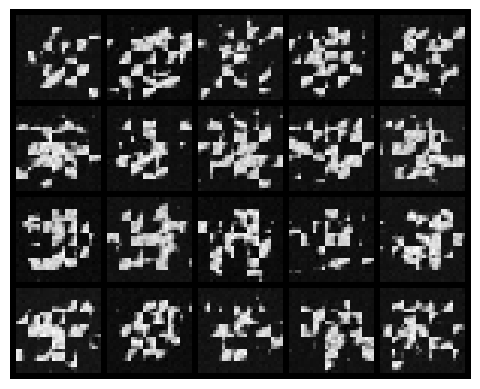

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.82it/s]


Avg Loss: 0.08131774269076171


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


Avg Loss: 0.06967763630137133


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.70it/s]


...

Avg Loss: 0.0483321387654365


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.18it/s]


Avg Loss: 0.04737363309303581


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.33it/s]


Avg Loss: 0.04677601745610298
Epoch: 11
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 59.077171325683594


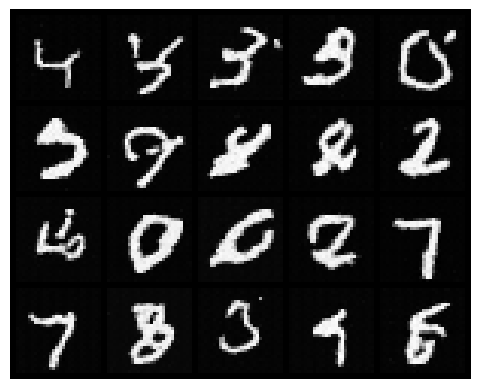

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:00<00:00, 15.46it/s]


Avg Loss: 0.046076219846635486


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.25it/s]


Avg Loss: 0.04597304500480578


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.84it/s]


...

Avg Loss: 0.04410155334158429


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.89it/s]


Avg Loss: 0.04383684903867781


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.04357779428942689
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 48.11210632324219


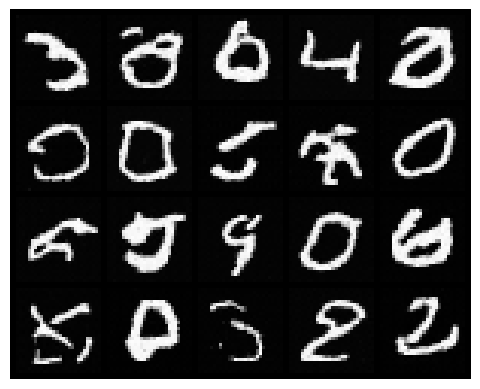

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.29it/s]


Avg Loss: 0.043351431222342605


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.19it/s]


Avg Loss: 0.04306511244555907


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.95it/s]


...

Avg Loss: 0.0425472020336401


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.77it/s]


Avg Loss: 0.04229033077314401


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.68it/s]


Avg Loss: 0.04208132914547473
Epoch: 31
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 36.36958694458008


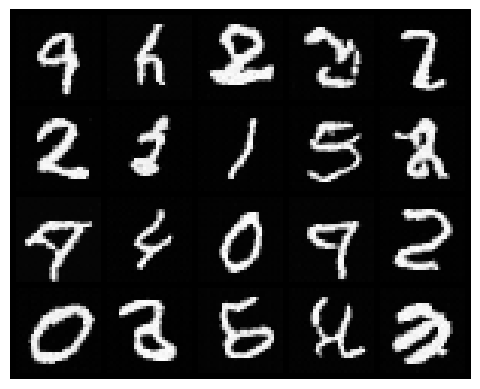

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.55it/s]


Avg Loss: 0.04205396358988115


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.04207741908395468


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:05<00:00, 14.43it/s]


...

Avg Loss: 0.0415820744353285


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.60it/s]


Avg Loss: 0.041351313128876785


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.56it/s]


Avg Loss: 0.041274844573489004
Epoch: 41
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 38.92129135131836


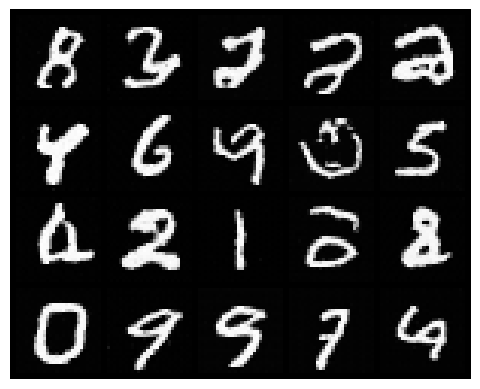

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.84it/s]


Avg Loss: 0.041371028592337426


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.33it/s]


Avg Loss: 0.04127233570167568


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.85it/s]


...

Avg Loss: 0.041137699371398384


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.040998775476236336


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.00it/s]


Avg Loss: 0.041074667348345716
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 36.81208419799805


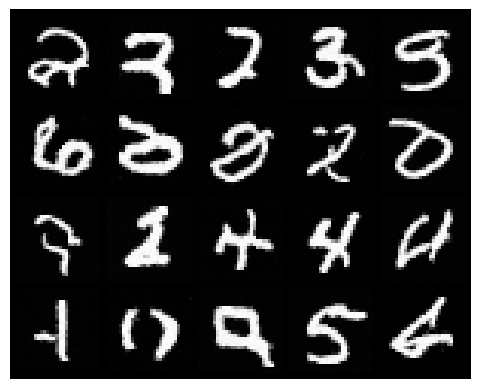

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.94it/s]


Avg Loss: 0.04093569248064812


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.92it/s]


Avg Loss: 0.04097230936577325


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.85it/s]


...

Avg Loss: 0.04079391984050589


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


Avg Loss: 0.04073316297694437


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.86it/s]


Avg Loss: 0.04060718768250459
Epoch: 61
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 37.3053092956543


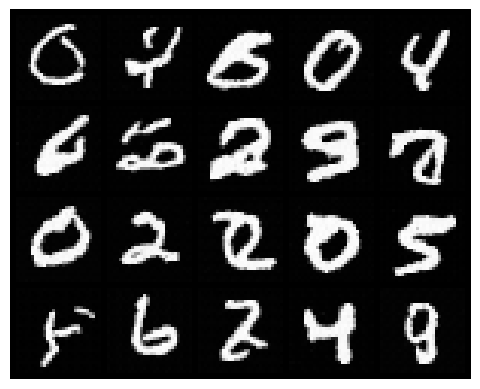

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.89it/s]


Avg Loss: 0.04048462087379844


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.93it/s]


Avg Loss: 0.04042551866663036


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


...

Avg Loss: 0.040298216070717714


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04037482439002185


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.04015397883729258
Epoch: 71
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 37.58024978637695


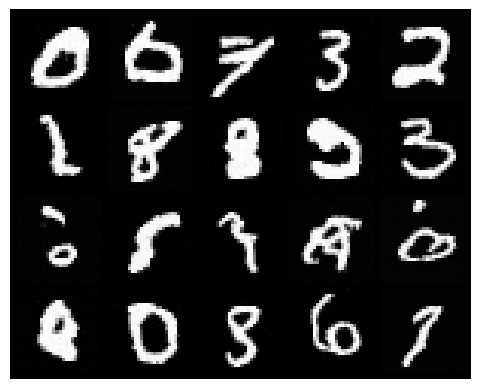

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.22it/s]


Avg Loss: 0.03988894727279637


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.86it/s]


Avg Loss: 0.0402502487900097


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.05it/s]


...

Avg Loss: 0.03999062759011412


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.83it/s]


Avg Loss: 0.039920581971356735


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.08it/s]


Avg Loss: 0.0398606364327326
Epoch: 81
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 33.2996940612793


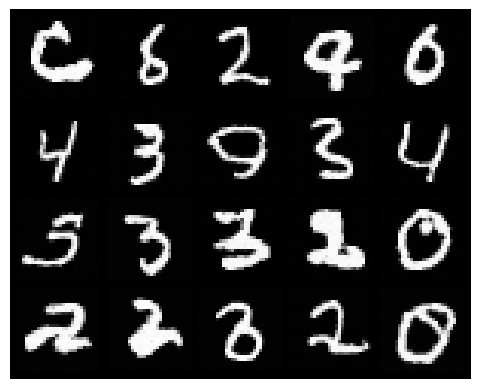

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.03it/s]


Avg Loss: 0.03986564993477071


 91%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                | 851/938 [00:56<00:05, 15.02it/s]


KeyboardInterrupt: 

In [ ]:
d = Diffusion()

d.train()

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 82


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.94it/s]


Avg Loss: 0.039672424975059815


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.11it/s]


Avg Loss: 0.039863672627727866


...

Avg Loss: 0.03954051128590603


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.45it/s]


Avg Loss: 0.03957681538366369


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.05it/s]


Avg Loss: 0.03982348371146203
Epoch: 91
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 38.900962829589844


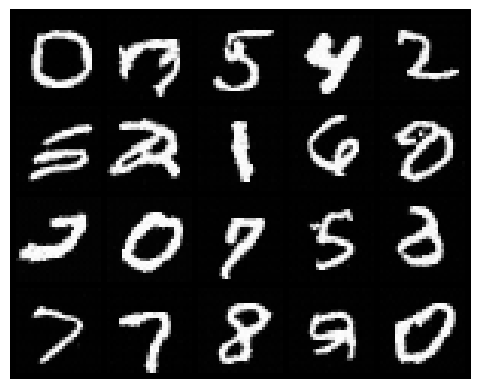

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:05<00:00, 14.30it/s]


Avg Loss: 0.039589885066249476


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.10it/s]


Avg Loss: 0.03996272381943172


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.07it/s]


...

Avg Loss: 0.039346499839174084


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.15it/s]


Avg Loss: 0.03940286389045687


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.97it/s]


Avg Loss: 0.03958335052381383
Final Epoch:


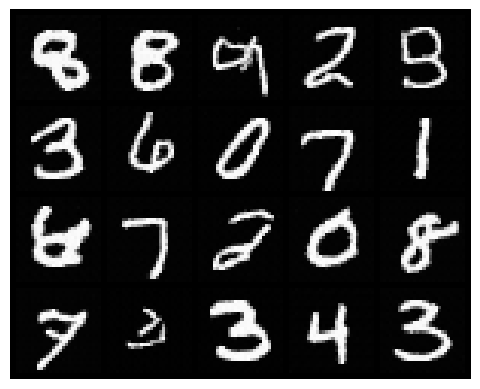

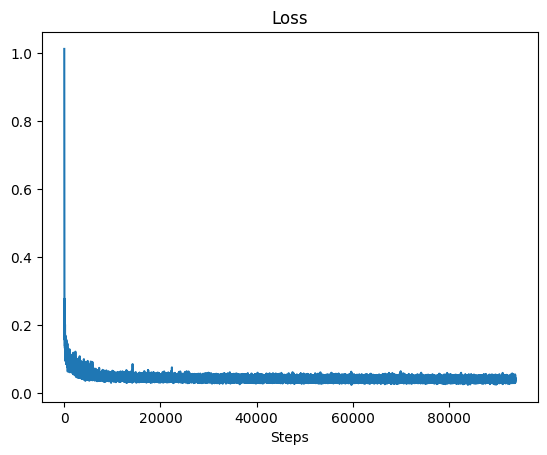

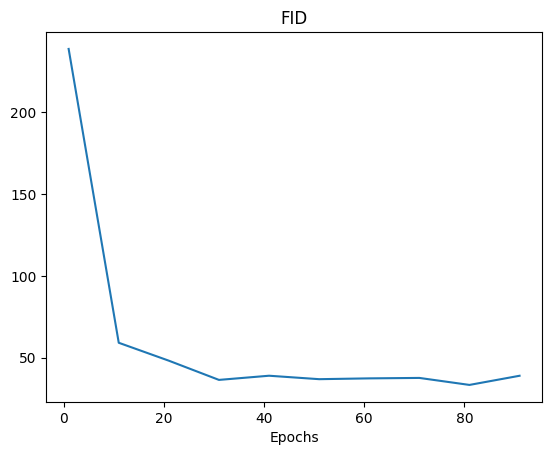

In [7]:
d = Diffusion()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

## Extra Credit: Complete any extra credit here